In [18]:
%load_ext autoreload
%autoreload 2

# general
from pathlib import Path
import re
import numpy as np
import datetime
import matplotlib.pyplot as plt
import itertools
from tqdm.auto import tqdm
import yaml
import subprocess

# spatial
import xarray as xa
import xarray as xa

# custom
from cmipper import utils, config, file_ops, processing

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Integrating `esgpull`

`esgpull` provides streamlined, maintained functionality to search and download files from the `esgf-node` servers. The job of this notebook is to substitute my own downloading schema (developed as `cmipper`) for `esgpull` while retaining the additional functionality I require. This is:
- ~~Consistent, human-readable file labelling~~ -> Happy with what's given, keeping for simplicity
- Regridding from variable grid to fixed grid
- POTENTIALLY – concatenating and cropping variables

This should enable faster, more reliable, and better-logged downloading of all necessary GCM variables in a 'one file' approach. The user should be able to specify which variables (at what resolution, over a specified time period), which model ensembles, and how many model runs they want for each. The program should then attempt to download these N times.

### Variables
| variable_long_name                                           | variable_id | variable_units | frequency                   |
|--------------------------------------------------------------|-------------|----------------|-----------------------------|
|                                                              |             |                |                             |
| Sea Surface Temperature                                      | tos         | [degC]         | 3hr, Amon, Oday, Odec, **Omon** |
| Sea Water Potential Temperature                              | thetao      | [degC]         | Omon                        |
| Downwelling Shortwave Radiation in Sea Water                 | rsdo        | [W m-2]        | Omon                        |
| Sea Water Salinity                                           | so          | [0.001]        | Omon                        |
| Sea Water X Velocity                                         | uo          | [m s-1]        | Odec, **Omon**                  |
| Sea Water Y Velocity                                         | vo          | [m s-1]        | Odec, **Omon**                  |
| Aragonite Concentration                                      | arag        | [mol m-3]      | Oyr                         |
| Dissolved Nitrate Concentration                              | no3         | [mol m-3]      | **Omon**, Oyr                   |
| Total Dissolved Inorganic Phosphorus Concentration           | po4         | [mol m-3]      | **Omon**, Oyr                   |

Working list:
1. ~~For an example ensemble (`HadGEM3-GC31-MM`) and variable (`tos`), search and download via command-line~~
2. ~~Automate this with a bash script~~ Done to some extent by generating query from yaml file
3. Pipe downloads into regridder

Example query:
`$ esgpull search project:CMIP6 experiment_id:historical institution_id:HadGEM3-GC31-MM variable_id:tos table_id:Omon member_id:r1i1p1f1 --distrib true --show`

In [ ]:
# creating searchs from yaml

with open('/maps/rt582/cmipper/tmp/data_to_download.yaml', 'r') as file:
    config = yaml.safe_load(file)

# Start the command as a list
query = ["esgpull", "search"]

# Add parameters, handling spaces by keeping each argument separate
for param, value in config.items():
    if not isinstance(value, list):
        # If there's a space, wrap value in quotes
        query.append(f"{param}:{value}" if ' ' not in str(value) else f"{param}:'{value}'")
    else:
        # Join list values with commas and wrap if they have spaces
        joined_values = ','.join([f"'{v}'" if ' ' in str(v) else v for v in value])
        query.append(f"{param}:{joined_values}")

# Add the distribution flag
query.append("--distrib")
query.append("true")

# Display the final command
print("Running:\n", ' '.join(query))

# Uncomment to execute the command
# subprocess.run(query)

Running:
 esgpull search project:CMIP6 nominal_resolution:'25 km' realm:atmos,ocean source_id:ECMWF-IFS-HR institution_id:ECMWF experiment_id:hist-1950 table_id:Omon,Amon variable_id:tos,rsds,so,uo --distrib true


# Testing processing functions

In [ ]:
# open test file
test_fp = "/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r1i1p1f1/Omon/vo/gn/v20170915/vo_Omon_ECMWF-IFS-HR_hist-1950_r1i1p1f1_gn_195001-195012.nc"
# select level
out = processing.extract_dataset_level(test_fp, 0)

# Processing resulting files

In [97]:
raw_data_dir = Path('/maps/rt582/cmipper/.esgpull/data/')
processed_data_dir = Path('/maps/rt582/cmipper/data/test/')

file_path = Path(test_fp)
rel_path = file_path.relative_to(raw_data_dir)

output_path = processed_data_dir / rel_path
output_path.parent.mkdir(parents=True, exist_ok=True)

# processing metadata
with open('/maps/rt582/cmipper/tmp/data_processing.yaml', 'r') as file:
    data_processing_config = yaml.safe_load(file)

select_level = data_processing_config["select_level"]
do_regrid = data_processing_config["do_regrid"]
output_grid = data_processing_config["output_grid"]
remap_method = data_processing_config["remap_method"]
do_delete_original = data_processing_config["do_delete_original"]

In [ ]:
remap_template_fp = output_path.parent / "remap_template.txt"
# generate remap file if necessary
remap_template_fp = utils.return_remap_template(input_file=out, remap_template_fp=remap_template_fp, out_grid=output_grid)

In [137]:
test = processing.reproject_xa_d(xa_d=out, ds_fp=test_fp, output_grid=output_grid, remap_method=remap_method)

Using existing remapping template at  /maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r1i1p1f1/Omon/vo/gn/v20170915/latlon_remap_template.txt


## Processing files once they've been downloaded
(Rather than on the fly)



In [ ]:
# for nc files in the lowest directories

# fetch all subdirectories
subdirs = [subdir for subdir in Path(raw_data_dir).glob("**/") 
                  if "deprecated" not in str(subdir) and subdir.is_dir()]

# select correct level(s)
for subdir in tqdm(subdirs, desc="Processing raw data to extract levels...", total = len(subdirs)):
    print(subdir)
    processing.process_raw_data_directory(subdir, chunk_schema=None, delete_og=do_delete_original)
# resave to same fp
# regrid to new location

Processing raw data to extract levels...:   0%|          | 0/110 [00:00<?, ?it/s]

/maps/rt582/cmipper/.esgpull/data
/maps/rt582/cmipper/.esgpull/data/CMIP6
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP
/maps/rt582/cmipper/.esgpull/data/CMIP6/ScenarioMIP
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r2i1p1f1
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r1i1p1f1
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r6i1p1f1
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r5i1p1f1
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r4i1p1f1
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3

	Processing so_Omon_ECMWF-IFS-HR_hist-1950_r3i1p1f1_gn_199801-199812...


	Processing so_Omon_ECMWF-IFS-HR_hist-1950_r3i1p1f1_gn_200101-200112...


	Processing so_Omon_ECMWF-IFS-HR_hist-1950_r3i1p1f1_gn_196601-196612...


	Processing so_Omon_ECMWF-IFS-HR_hist-1950_r3i1p1f1_gn_195201-195212...


In [43]:
ds_eg = processing.load_dataset_with_dask(test_fp, chunk_schema={"time": 1, "lev": -1})
# extract seafloor indices 
seafloor_inds = processing.gen_seafloor_indices(ds_eg, "vo")


determining seafloor indices... 


In [80]:
import time

def benchmark_chunking_schemas(ds, variable_id, seafloor_indices, schemas):
    times = {}
    
    for name, chunks in schemas.items():
        print(f"Testing chunking schema: {name}")
        
        # Re-chunk the dataset based on the current schema
        ds_chunked = ds.chunk(chunks)
        
        # Start the timer and apply extraction function
        start_time = time.time()
        
        # Extract seafloor values with the current chunking schema
        processing.extract_seafloor_vals_from_ds(ds_chunked, variable_id, seafloor_indices)
        
        # Record the time taken
        times[name] = time.time() - start_time
        print(f"Time for {name}: {times[name]:.2f} seconds")
        
    return times

# Define your chunking schemas
chunk_schema = {
    "auto": "auto",
    "all_levs": {"time": 1, "lev": -1},
    "all_time": {"time": -1, "lev": 1},
    "all_time_all_levs": {"time": -1, "lev": -1},
    "None": None,
    "balanced": {"time": 5, "lev": 10},
    "lev_10": {"time": 1, "lev": 10},
    "lev_20": {"time": 1, "lev": 20},
    "lev_30": {"time": 1, "lev": 30},
    "lev_40": {"time": 1, "lev": 40},
    "lev_50": {"time": 1, "lev": 50},
    "lev_60": {"time": 1, "lev": 60},
    "lev_70": {"time": 1, "lev": 70},
}

# Run the benchmark
new_times = benchmark_chunking_schemas(ds_eg, "vo", seafloor_inds, chunk_schema)
print("Chunking times:", new_times)

Testing chunking schema: None
Time for None: 26.96 seconds
Chunking times: {'None': 26.95549964904785}


In [81]:
times.update(new_times)

/tmp/ipykernel_3726440/4055431895.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Key', y='Value', palette="viridis")


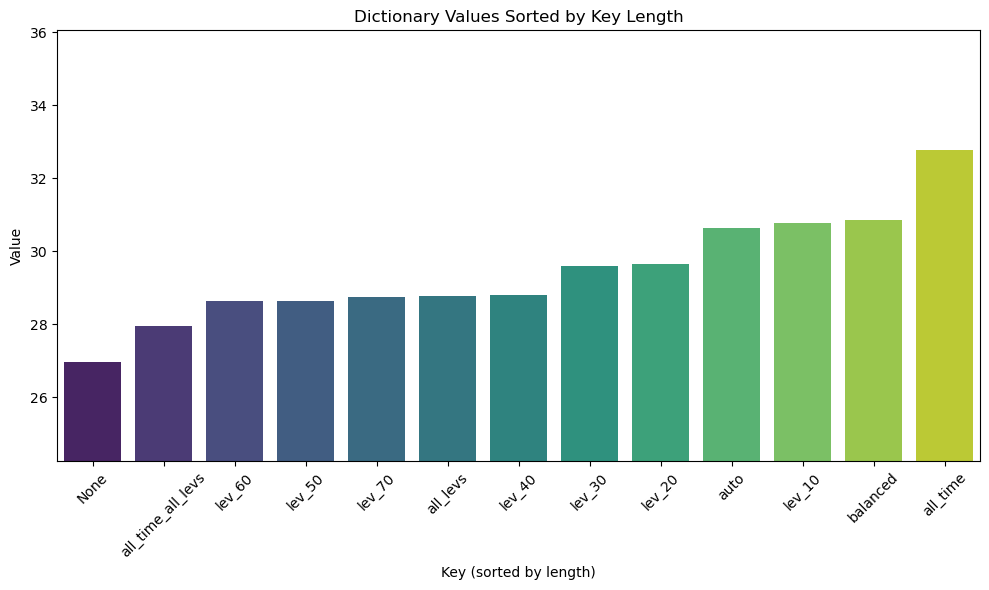

In [82]:
import pandas as pd
import seaborn as sns
sorted_times = dict(sorted(times.items(), key=lambda item: item[1]))
# Convert to DataFrame for easier plotting
df = pd.DataFrame(list(sorted_times.items()), columns=['Key', 'Value'])
df['Key_Length'] = df['Key'].apply(len)  # Add a column for key length if you want to color by this

# Plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Key', y='Value', palette="viridis")

# Customize plot
plt.xlabel("Key (sorted by length)")
plt.ylabel("Value")
plt.title("Dictionary Values Sorted by Key Length")
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(min(times.values()) * 0.9, max(times.values()) * 1.1)
plt.show()


In [94]:
lev_fp = "/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/so/gn/v20181119/extracted_lev/so_Omon_ECMWF-IFS-HR_hist-1950_r3i1p1f1_gn_200101-200112.nc"
xa.open_dataset(lev_fp)

<xarray.Dataset> Size: 130MB
Dimensions:             (time: 12, bnds: 2, lev: 75, i: 1021, j: 1442,
                         vertices: 4)
Coordinates:
  * time                (time) datetime64[ns] 96B 2001-01-16T12:00:00 ... 200...
  * lev                 (lev) float64 600B 0.5058 1.556 ... 5.698e+03 5.902e+03
  * i                   (i) int32 4kB 1 2 3 4 5 6 ... 1017 1018 1019 1020 1021
  * j                   (j) int32 6kB 1 2 3 4 5 6 ... 1438 1439 1440 1441 1442
    latitude            (i, j) float32 6MB ...
    longitude           (i, j) float32 6MB ...
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) datetime64[ns] 192B ...
    lev_bnds            (lev, bnds) float64 1kB ...
    vertices_latitude   (i, j, vertices) float32 24MB ...
    vertices_longitude  (i, j, vertices) float32 24MB ...
    so                  (time, i, j) float32 71MB ...
Attributes: (12/52)
    Conventions:             CF-1.7 CMIP-6.0
    activity_id:             HighResMIP
    branch_method:           Initialized directly from parent restart files
    contact:                 chris.roberts@ecmwf.int
    creation_date:           2017-08-09T03:57:52Z
    end_year:                2014
    ...                      ...
    further_info_url:        https://furtherinfo.es-doc.org/CMIP6.ECMWF.ECMWF...
    data_specs_version:      01.00.23
    institution:             European Centre for Medium-Range Weather Forecas...
    references:              Roberts, C. D., Senan, R., Molteni, F., Boussett...
    source:                  ECMWF-IFS-HR (2017): \naerosol: none\natmos: IFS...
    history:                 2017-08-09T03:57:52Z CMOR rewrote data to be con...